In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pickle


In [3]:
# Load datasets
genes = pd.read_csv('data.csv')   # <-- store it properly
genes = genes.drop(columns=[genes.columns[0]])  # Drop Unnamed: 0 column (sample ID)

labels = pd.read_csv('labels.csv')

print("Genes Shape:", genes.shape)
print("Labels Shape:", labels.shape)
print(labels.head())


Genes Shape: (801, 20531)
Labels Shape: (801, 2)
  Unnamed: 0 Class
0   sample_0  PRAD
1   sample_1  LUAD
2   sample_2  PRAD
3   sample_3  PRAD
4   sample_4  BRCA


In [4]:
# Select correct column
target = labels['Class']

# Map cancer types
label_mapping = {'BRCA': 0, 'COAD': 1, 'KIRC': 2, 'LUAD': 3, 'PRAD': 4}
target_mapped = target.map(label_mapping)

# Drop samples with other cancers
mask_valid = target_mapped.notna()
genes = genes[mask_valid].reset_index(drop=True)
target_mapped = target_mapped[mask_valid].reset_index(drop=True)

print("After cleaning:", genes.shape, target_mapped.shape)
print(target_mapped.value_counts())


After cleaning: (801, 20531) (801,)
Class
0    300
2    146
3    141
4    136
1     78
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    genes, target_mapped, test_size=0.2, random_state=42, stratify=target_mapped)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (640, 20531)
Testing Data: (161, 20531)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
mi_scores = mutual_info_classif(X_train_scaled, y_train)

# Top 50
top50_idx = np.argsort(mi_scores)[-50:]

X_train_top50 = X_train_scaled[:, top50_idx]
X_test_top50 = X_test_scaled[:, top50_idx]

print(X_train_top50.shape, X_test_top50.shape)


(640, 50) (161, 50)


In [8]:
np.save('top50_idx.npy', top50_idx)


In [9]:
# Initialize SVM with RBF Kernel + balanced class weight
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Forward Selection
sfs = SFS(
    svm_model,
    k_features=10,
    forward=True,
    floating=False,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

sfs = sfs.fit(X_train_top50, y_train)

selected_features_idx = list(sfs.k_feature_idx_)
print("Selected Features Indices:", selected_features_idx)

# Subset
X_train_selected = X_train_top50[:, selected_features_idx]
X_test_selected = X_test_top50[:, selected_features_idx]


Selected Features Indices: [1, 3, 12, 27, 28, 30, 34, 38, 39, 48]


In [10]:
# Create a new scaler ONLY for the selected 10 features
scaler_10 = StandardScaler()
scaler_10.fit(X_train_selected)

# Save this smaller scaler
import pickle
with open('scaler_10.pkl', 'wb') as f:
    pickle.dump(scaler_10, f)


In [11]:
final_svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
final_svm.fit(X_train_selected, y_train)


SVC(class_weight='balanced', random_state=42)

In [12]:
# Predict
y_pred = final_svm.predict(X_test_selected)

# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted')*100:.2f}%")

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 98.76%
Precision: 98.77%
Recall: 98.76%
F1-Score: 98.75%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       1.00      0.94      0.97        16
           2       1.00      1.00      1.00        30
           3       0.96      0.96      0.96        28
           4       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.98      0.98       161
weighted avg       0.99      0.99      0.99       161



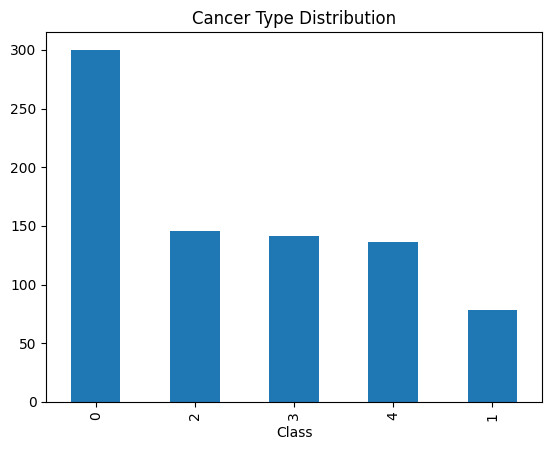

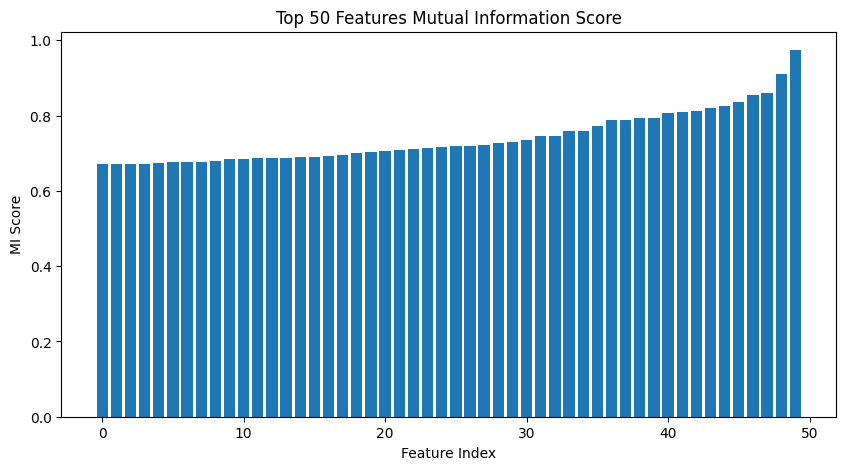

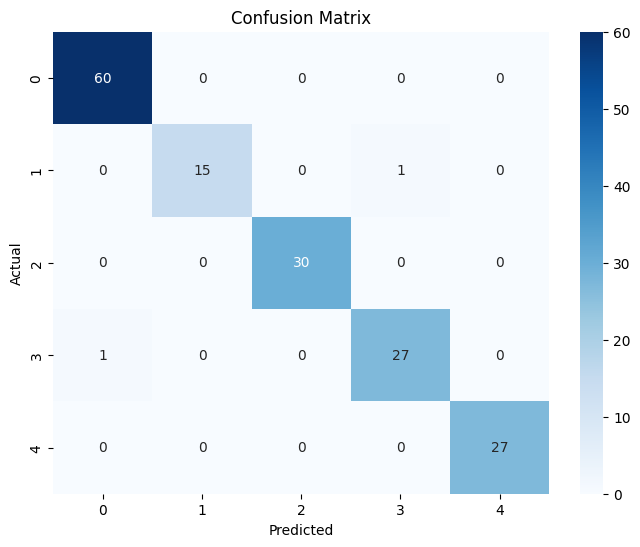

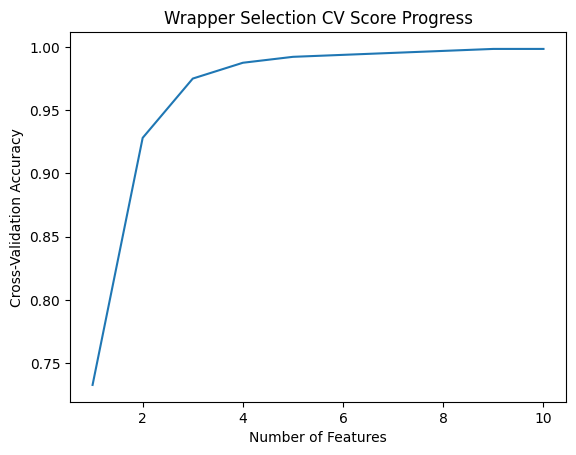

In [13]:
# 1. Cancer Type Distribution
target_mapped.value_counts().plot(kind='bar', title='Cancer Type Distribution')
plt.show()

# 2. Top 50 Feature MI Scores
plt.figure(figsize=(10,5))
plt.bar(range(50), mi_scores[top50_idx])
plt.title('Top 50 Features Mutual Information Score')
plt.xlabel('Feature Index')
plt.ylabel('MI Score')
plt.show()

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. Wrapper Selection Progress
plt.plot(range(1, len(sfs.get_metric_dict().keys())+1),
         [v['avg_score'] for v in sfs.get_metric_dict().values()])
plt.title('Wrapper Selection CV Score Progress')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.show()



In [14]:
# Save model and selected features
with open('cancer_model.pkl', 'wb') as f:
    pickle.dump(final_svm, f)

np.save('selected_features_idx.npy', selected_features_idx)


In [15]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


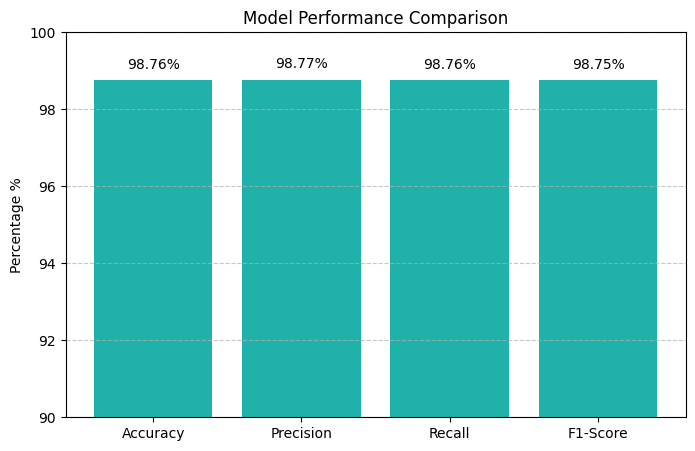

In [16]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [98.76, 98.77, 98.76, 98.75]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores, color='lightseagreen')
plt.title('Model Performance Comparison')
plt.ylim(90, 100)
for i, v in enumerate(scores):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha='center')
plt.ylabel('Percentage %')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [17]:
import pickle

# Load your trained model
model = pickle.load(open('cancer_model.pkl', 'rb'))


In [18]:
import numpy as np

# Load indices of selected 10 features
selected_features_idx = np.load('selected_features_idx.npy')


In [19]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Generate 1 row with 20,531 random float values (standard normal)
sample_values = np.random.normal(loc=0, scale=1, size=(1, 20531))

# Create DataFrame
sample_df = pd.DataFrame(sample_values)

# Save to CSV
sample_df.to_csv('sample_full_gene.csv', index=False)
